In [1]:
! pip install torch
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt

In [2]:
# Generate 1000 hours of simulated smart grid & weather data
np.random.seed(42)
timesteps = 1000
# Simulated Variables
tempreature = 25 + 10 * np.sin(np.linspace(0,50,timesteps)) + np.random.normal(0,1,timesteps)
humidity = 60 + 15 * np.cos(np.linspace(0,50,timesteps)) + np.random.normal(0,2,timesteps)
energy_demand = 50 + 20 * np.sin(np.linspace(0,50,timesteps)) + (tempreature * 0.5) + np.random.normal(0,3,timesteps)


In [3]:
# Create DataFrame
df_grid = pd.DataFrame({
    'tempreature' : tempreature,
    'humidity' : humidity,
    'energy_demand' : energy_demand
    
})
print('---Dataset Matrix Initialized')
print(df_grid.head())

---Dataset Matrix Initialized
   tempreature   humidity  energy_demand
0    25.496714  77.798711      60.722822
1    25.362027  76.830484      63.248041
2    26.647019  75.044173      62.944910
3    28.018896  73.537356      66.077295
4    26.754502  76.096848      61.673718


In [4]:
# Scale Feature between 0 and 1
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(df_grid)

# Windowing Function

def create_sequences (data,seq_length):
    X,y = [],[]
    for i in range(len(data)-seq_length):
        X.append(data[i:(i + seq_length)]) # Past history window
        y.append(data[i + seq_length,2]) # Target variable energy demand at next hour
    return np.array(X),np.array(y)
    
# look back at the past 24 hours

lookback = 24
X,y = create_sequences(scaled_data,lookback)


In [5]:
# Split into test and train data
train_size = int(len(X)*0.8)
X_train,X_test = X[:train_size],X[train_size:]
y_train,y_test = y[:train_size],y[train_size:]

In [6]:
# Convert arrays into pytorch Tensors
X_train_tensor = torch.tensor(X_train,dtype=torch.float32)
y_train_tensor = torch.tensor(y_train,dtype=torch.float32).unsqueeze(-1)
X_test_tensor = torch.tensor(X_test,dtype=torch.float32)
y_test_tensor = torch.tensor(y_test,dtype=torch.float32).unsqueeze(-1)
print(f"Training Shapes -> Features: {X_train_tensor.shape}, Targets: {y_train_tensor.shape}")

Training Shapes -> Features: torch.Size([780, 24, 3]), Targets: torch.Size([780, 1])


In [10]:
import torch.nn as nn

class SmartGridLSTM(nn.Module):
    def __init__(self, input_dim, hidden_dim, num_layers, output_dim=1):
        super(SmartGridLSTM, self).__init__()
        
        self.hidden_dim = hidden_dim
        self.num_layers = num_layers
        
        # 1. The LSTM Layer: processes the sequential weather/load data
        # batch_first=True tells PyTorch our inputs look like [Batch, Sequence, Feature]
        self.lstm = nn.LSTM(input_size=input_dim, 
                            hidden_size=hidden_dim, 
                            num_layers=num_layers, 
                            batch_first=True)
        
        # 2. Fully Connected Dense Layer: maps the final hidden state to a single prediction
        self.fc = nn.Linear(hidden_dim, output_dim)
        
    def forward(self, x):
        # Initialize hidden state and cell state with zeros
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_dim)
        c0 = torch.zeros(self.num_layers, x.size(0), self.hidden_dim)
        
        # Forward pass through the LSTM layer
        # out shape: [Batch, Sequence, Hidden_Dim]
        out, (hn, cn) = self.lstm(x, (h0, c0))
        
        # Pass ONLY the final time step's output (hour 24) into the linear layer
        out = self.fc(out[:, -1, :])
        return out

# Instantiate the model
INPUT_DIM = 3    # Temperature, Humidity, Demand
HIDDEN_DIM = 64  # Number of internal neural pathways
NUM_LAYERS = 2   # Stacking 2 LSTMs for deeper pattern recognition

model = SmartGridLSTM(input_dim=INPUT_DIM, hidden_dim=HIDDEN_DIM, num_layers=NUM_LAYERS)
print("LSTM Model Structural Graph Initialized Successfully!")
print(model)

LSTM Model Structural Graph Initialized Successfully!
SmartGridLSTM(
  (lstm): LSTM(3, 64, num_layers=2, batch_first=True)
  (fc): Linear(in_features=64, out_features=1, bias=True)
)


In [11]:
# Mean Squared error loss 
criterion = nn.MSELoss()
# Adam Optimizer handles complex multi variable gradient descent 
optimizer = torch.optim.Adam(model.parameters(),lr=0.005)
print("---Loss Function & Optimization Parameters Established---")

---Loss Function & Optimization Parameters Established---


In [12]:
num_epochs = 100
train_losses = []
print("---Started Deep Learning Loop---")
print("---------------------------------")
for epoch in range(num_epochs):
    model.train()
    # Clear previous calculations
    optimizer.zero_grad()
    # forward pass make predictions
    outputs=model(X_train_tensor)
    # Calculate the error loss
    loss = criterion(outputs,y_train_tensor)
    # Backward pass calculate how to update the weights
    loss.backward()
    # Apply Updates
    optimizer.step()

    train_losses.append(loss.item())
    # print progress every 10 cycles
    if(epoch + 1) % 10 == 0:
        print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {loss.item():.6f}")

print("----------------------------------------")
print('Training Completed')

---Started Deep Learning Loop---
---------------------------------
Epoch [10/100], Loss: 0.094175
Epoch [20/100], Loss: 0.051092
Epoch [30/100], Loss: 0.017398
Epoch [40/100], Loss: 0.004123
Epoch [50/100], Loss: 0.002721
Epoch [60/100], Loss: 0.002425
Epoch [70/100], Loss: 0.002314
Epoch [80/100], Loss: 0.002259
Epoch [90/100], Loss: 0.002249
Epoch [100/100], Loss: 0.002244
----------------------------------------
Training Completed


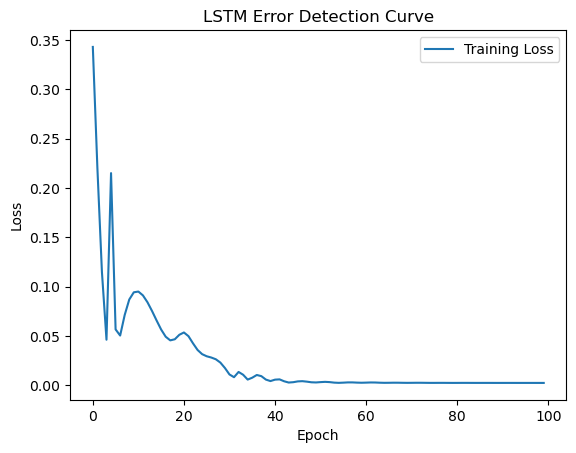

In [13]:
plt.plot(train_losses,label='Training Loss')
plt.title('LSTM Error Detection Curve')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [14]:
# 1. Put the model in evaluation mode
model.eval()

with torch.no_grad():
    # Make a prediction on a sample from our test data
    # Let's take the first window from the test split
    sample_input = X_test_tensor[0].unsqueeze(0) # Shape: [1, 24, 3]
    predicted_scaled = model(sample_input).item()
    actual_scaled = y_test_tensor[0].item()

# 2. To make it meaningful, let's upscale the value back to normal Megawatts (MW)
# Based on our synthetic data generation, max load was around 80 MW
max_demand = df_grid['energy_demand'].max()
min_demand = df_grid['energy_demand'].min()

predicted_mw = predicted_scaled * (max_demand - min_demand) + min_demand
actual_mw = actual_scaled * (max_demand - min_demand) + min_demand

print(f"📊 Live System Inference Output:")
print(f"-> Predicted Grid Load: {predicted_mw:.2f} MW")
print(f"-> Actual Grid Load:    {actual_mw:.2f} MW\n")
print("==================================================")
print("🤖 AUTOMATED GRID DECISION LOG ACTIVATED")
print("==================================================")

# 3. THE DECISION MATRIX ("What Next" Business Logic)
GRID_CAPACITY = 65.0 # The safe baseline capacity of the city's green grid in MW

if predicted_mw > GRID_CAPACITY:
    deficit = predicted_mw - GRID_CAPACITY
    print(f"🚨 CRITICAL WARNING: Predicted Load ({predicted_mw:.2f} MW) exceeds normal capacity by {deficit:.2f} MW!")
    print("Executing Protocol Alpha: Sending API throttling commands to public EV Charging Stations.")
    print("Executing Protocol Beta: Discharging 15MW from Municipal Battery Storage Banks to stabilize lines.")
    print("Executing Protocol Gamma: Blasting consumer alert via App Database: 'Peak Demand Spike Imminent. Please minimize high-load appliances.'")

elif predicted_mw < 40.0:
    surplus = GRID_CAPACITY - predicted_mw
    print(f"☀️ GREEN ENERGY SURPLUS DETECTED: Expected load drops to {predicted_mw:.2f} MW. Grid surplus: {surplus:.2f} MW.")
    print("Executing Protocol Delta: Rerouting excess power to Pumped Hydroelectric Storage Facilities.")
    print("Executing Protocol Epsilon: Activating Dynamic Pricing Database Update -> Dropping unit cost by 40% for the next 3 hours.")

else:
    print(f"✅ GRID STABLE: Predicted Load ({predicted_mw:.2f} MW) is within safe operational thresholds.")
    print("Action: Maintaining baseline power distribution loops. No overrides required.")

📊 Live System Inference Output:
-> Predicted Grid Load: 77.77 MW
-> Actual Grid Load:    76.12 MW

🤖 AUTOMATED GRID DECISION LOG ACTIVATED
🚨 CRITICAL WARNING: Predicted Load (77.77 MW) exceeds normal capacity by 12.77 MW!
Executing Protocol Alpha: Sending API throttling commands to public EV Charging Stations.
Executing Protocol Beta: Discharging 15MW from Municipal Battery Storage Banks to stabilize lines.
Executing Protocol Gamma: Blasting consumer alert via App Database: 'Peak Demand Spike Imminent. Please minimize high-load appliances.'


In [15]:
import joblib

# 1. Save the PyTorch model weights
torch.save(model.state_dict(), 'smart_grid_lstm.pth')

# 2. Save the fitted scaler so the web app can normalize user inputs exactly like our training loop
joblib.dump(scaler, 'grid_scaler.pkl')

print("Model weights and scaler successfully exported for production deployment!")

Model weights and scaler successfully exported for production deployment!
